In [25]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 设置科研绘图风格
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

In [26]:
# 读取colas.csv数据
data_path = '../../SourceData/colas.csv'
df = pd.read_csv(data_path)

# 转换时间列为datetime格式
df['time'] = pd.to_datetime(df['time'])

# 显示数据基本信息
print("Data Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
df.head(10)

Data Shape: (114253, 11)

Column Names:
['Unnamed: 0', 'id', 'time', 'gl', 'gender', 'age', 'BMI', 'glycaemia', 'HbA1c', 'follow.up', 'T2DM']

First few rows:


,Unnamed: 0,id,time,gl,gender,age,BMI,glycaemia,HbA1c,follow.up,T2DM
0,0,1,2012-01-01 00:00:00,86.0,1.0,77.0,25.4,106.0,6.3,413.0,False
1,1,1,2012-01-01 00:05:00,81.0,1.0,77.0,25.4,106.0,6.3,413.0,False
2,2,1,2012-01-01 00:10:00,78.0,1.0,77.0,25.4,106.0,6.3,413.0,False
3,3,1,2012-01-01 00:15:00,76.0,1.0,77.0,25.4,106.0,6.3,413.0,False
4,4,1,2012-01-01 00:20:00,76.0,1.0,77.0,25.4,106.0,6.3,413.0,False
5,5,1,2012-01-01 00:25:00,77.0,1.0,77.0,25.4,106.0,6.3,413.0,False
6,6,1,2012-01-01 00:30:00,78.0,1.0,77.0,25.4,106.0,6.3,413.0,False
7,7,1,2012-01-01 00:35:00,80.0,1.0,77.0,25.4,106.0,6.3,413.0,False
8,8,1,2012-01-01 00:40:00,81.0,1.0,77.0,25.4,106.0,6.3,413.0,False
9,9,1,2012-01-01 00:45:00,82.0,1.0,77.0,25.4,106.0,6.3,413.0,False


In [27]:
# 数据统计摘要
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Unnamed: 0,id,time,gl,gender,age,BMI,glycaemia,HbA1c,follow.up
count,114253.00000,114253.000000,114253,114253.000000,114253.000000,114253.000000,114253.000000,114253.000000,114253.000000,114253.000000
mean,57126.00000,103.514551,2012-01-01 23:26:50.525281536,102.320342,0.508503,59.656430,29.960454,100.877038,5.766710,986.276023
min,0.00000,1.000000,2012-01-01 00:00:00,40.000000,0.000000,29.000000,18.100000,78.000000,5.100000,176.000000
25%,28563.00000,51.000000,2012-01-01 11:25:00,88.000000,0.000000,54.000000,27.000000,93.000000,5.600000,701.000000
50%,57126.00000,104.000000,2012-01-01 23:00:01,100.000000,1.000000,61.000000,29.400000,101.000000,5.766710,986.276023
75%,85689.00000,156.000000,2012-01-02 11:25:01,113.000000,1.000000,66.000000,32.400000,108.000000,5.900000,1232.000000
max,114252.00000,208.000000,2012-01-02 23:58:44,318.000000,2.000000,88.000000,48.700000,135.000000,6.500000,2211.000000
std,32982.14449,60.246477,NaN,21.805964,0.509915,9.968358,4.546004,11.359690,0.289851,363.653638


In [28]:
# 检查缺失值
print("Missing Values:")
print(df.isnull().sum())
print("\nMissing Percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))

Missing Values:
Unnamed: 0    0
id            0
time          0
gl            0
gender        0
age           0
BMI           0
glycaemia     0
HbA1c         0
follow.up     0
T2DM          0
dtype: int64

Missing Percentage:
Unnamed: 0    0.0
id            0.0
time          0.0
gl            0.0
gender        0.0
age           0.0
BMI           0.0
glycaemia     0.0
HbA1c         0.0
follow.up     0.0
T2DM          0.0
dtype: float64


In [29]:
# 获取唯一受试者数量
unique_subjects = df['id'].nunique()
print(f"Number of Unique Subjects: {unique_subjects}")
print(f"\nSubject IDs: {sorted(df['id'].unique())}")

Number of Unique Subjects: 208

Subject IDs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69

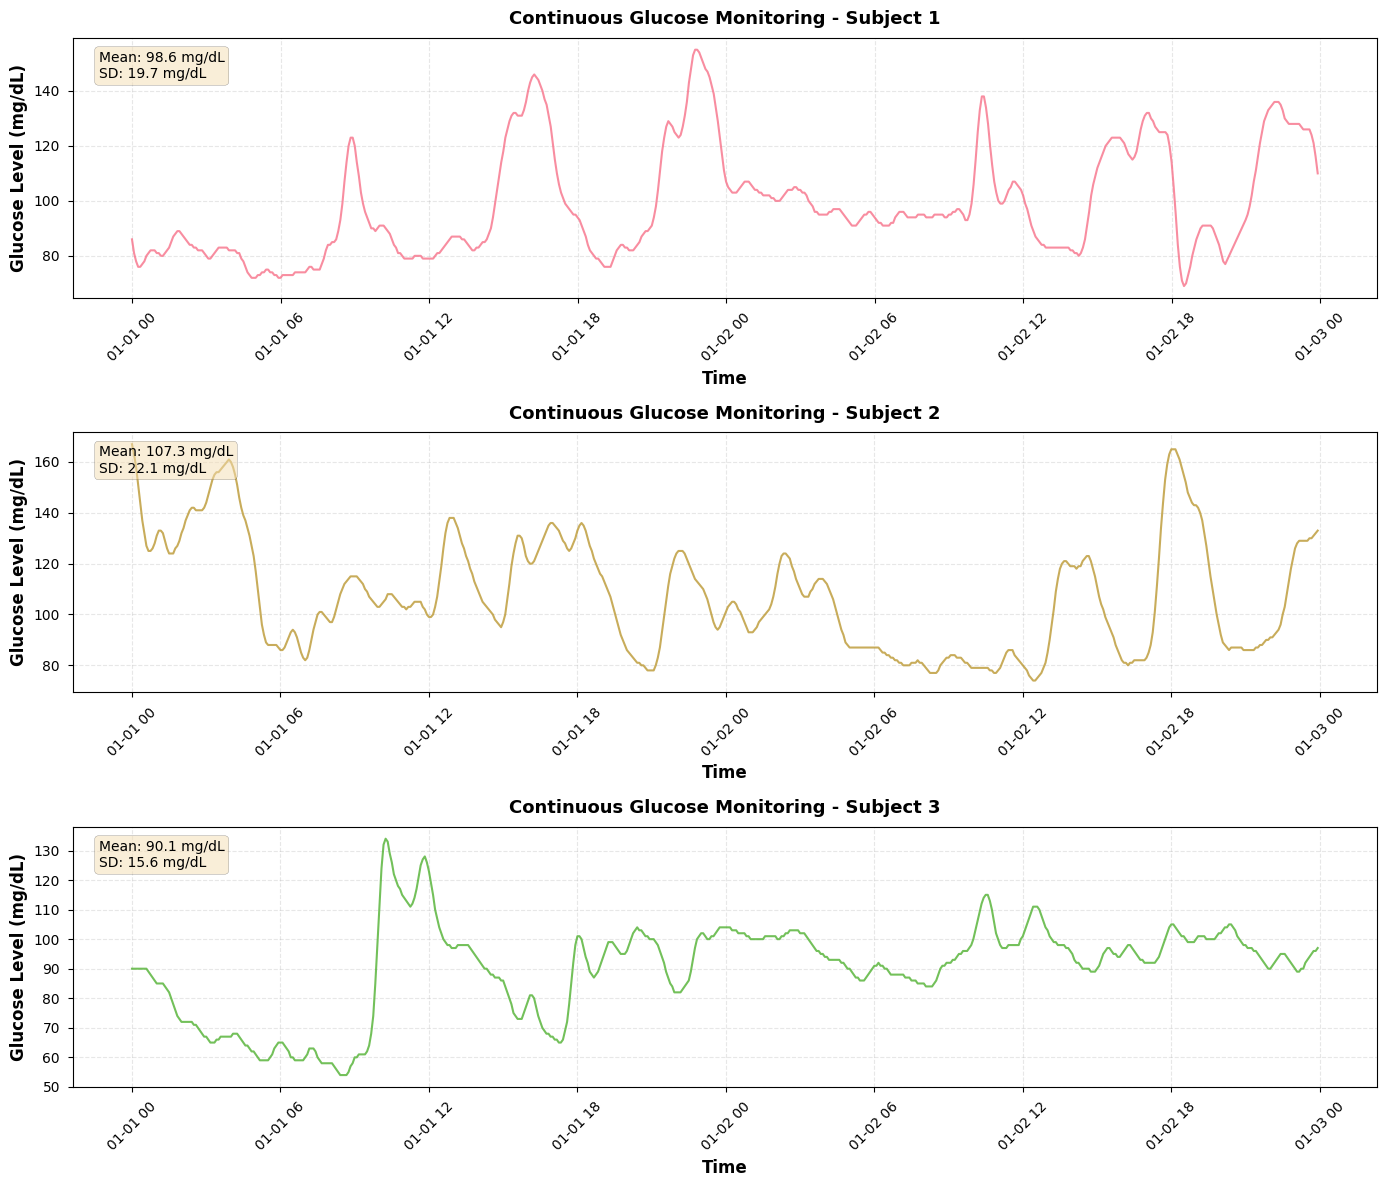

In [30]:
# 图1: 血糖时间序列图 (选择前3个受试者作为示例)
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 选择前3个受试者
sample_subjects = sorted(df['id'].unique())[:3]

for idx, subject_id in enumerate(sample_subjects):
    subject_data = df[df['id'] == subject_id].sort_values('time')
    
    axes[idx].plot(subject_data['time'], subject_data['gl'], 
                   linewidth=1.5, alpha=0.8, color=f'C{idx}')
    
    axes[idx].set_xlabel('Time', fontweight='bold')
    axes[idx].set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
    axes[idx].set_title(f'Continuous Glucose Monitoring - Subject {subject_id}', 
                        fontweight='bold', pad=10)
    axes[idx].grid(True, alpha=0.3, linestyle='--')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # 添加统计信息文本
    mean_gl = subject_data['gl'].mean()
    std_gl = subject_data['gl'].std()
    axes[idx].text(0.02, 0.95, f'Mean: {mean_gl:.1f} mg/dL\nSD: {std_gl:.1f} mg/dL', 
                   transform=axes[idx].transAxes, fontsize=10,
                   verticalalignment='top', bbox=dict(boxstyle='round', 
                   facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [40]:
# 噪声评估分析 - 判断是否需要滤波

# 步骤1: 计算所有受试者的噪声指标
print("="*70)
print("NOISE ASSESSMENT FOR FILTERING DECISION")
print("="*70)

noise_metrics = []
all_subjects = sorted(df['id'].unique())

for subject_id in all_subjects:
    subject_data = df[df['id'] == subject_id].sort_values('time').reset_index(drop=True)
    
    # 计算相邻点的差分（代表噪声）
    diff = subject_data['gl'].diff().dropna()
    
    # 噪声指标
    noise_std = diff.std()  # 噪声标准差
    noise_mean_abs = diff.abs().mean()  # 平均绝对变化
    
    # 信号变异性
    signal_std = subject_data['gl'].std()  # 信号标准差
    
    # 计算信噪比 (SNR = 信号变异 / 噪声变异)
    snr = signal_std / noise_std if noise_std > 0 else 0
    
    # 异常跳变比例（定义：5分钟内变化>5 mg/dL为异常）
    abnormal_changes = (diff.abs() > 5).sum()
    abnormal_ratio = abnormal_changes / len(diff) * 100
    
    noise_metrics.append({
        'subject_id': subject_id,
        'noise_std': noise_std,
        'noise_mean_abs': noise_mean_abs,
        'signal_std': signal_std,
        'snr': snr,
        'abnormal_ratio': abnormal_ratio,
        'total_points': len(subject_data)
    })

noise_df = pd.DataFrame(noise_metrics)

# 步骤2: 定义滤波需求标准
# 基于文献：健康人血糖变化率通常 < 2-3 mg/dL/5min
NOISE_THRESHOLD = 1.5  # mg/dL，平均绝对变化的阈值
ABNORMAL_THRESHOLD = 10.0  # %，异常跳变比例的阈值
SNR_THRESHOLD = 10.0  # 信噪比阈值，低于此值认为噪声过大

# 判断每个受试者是否需要滤波
noise_df['needs_filtering'] = (noise_df['noise_mean_abs'] > NOISE_THRESHOLD) | \
                               (noise_df['abnormal_ratio'] > ABNORMAL_THRESHOLD) | \
                               (noise_df['snr'] < SNR_THRESHOLD)

# 步骤3: 统计结果
need_filter_count = noise_df['needs_filtering'].sum()
total_subjects = len(noise_df)

print(f"\n步骤1: 噪声量化结果")
print(f"  - 平均噪声水平: {noise_df['noise_mean_abs'].mean():.2f} mg/dL (阈值: {NOISE_THRESHOLD})")
print(f"  - 平均异常跳变比例: {noise_df['abnormal_ratio'].mean():.1f}% (阈值: {ABNORMAL_THRESHOLD}%)")
print(f"  - 平均信噪比(SNR): {noise_df['snr'].mean():.2f} (阈值: >{SNR_THRESHOLD})")
print(f"  - SNR范围: [{noise_df['snr'].min():.2f}, {noise_df['snr'].max():.2f}]")

print(f"\n步骤2: 滤波需求判断")
print(f"  - 需要滤波的受试者: {need_filter_count}/{total_subjects} ({need_filter_count/total_subjects*100:.1f}%)")
print(f"  - 不需要滤波的受试者: {total_subjects-need_filter_count}/{total_subjects} ({(total_subjects-need_filter_count)/total_subjects*100:.1f}%)")

# 分类统计
low_snr_count = (noise_df['snr'] < SNR_THRESHOLD).sum()
high_noise_count = (noise_df['noise_mean_abs'] > NOISE_THRESHOLD).sum()
high_abnormal_count = (noise_df['abnormal_ratio'] > ABNORMAL_THRESHOLD).sum()

print(f"\n  具体原因分析:")
print(f"    - SNR过低 (<{SNR_THRESHOLD}): {low_snr_count} subjects")
print(f"    - 噪声过大 (>{NOISE_THRESHOLD} mg/dL): {high_noise_count} subjects")
print(f"    - 异常跳变过多 (>{ABNORMAL_THRESHOLD}%): {high_abnormal_count} subjects")

if need_filter_count / total_subjects > 0.5:
    print(f"\n✓ 结论: 超过50%受试者需要滤波 → 建议对所有数据进行统一滤波处理")
else:
    print(f"\n✓ 结论: 仅部分受试者需要滤波 → 可考虑个性化滤波策略")

print("="*70)

NOISE ASSESSMENT FOR FILTERING DECISION

步骤1: 噪声量化结果
  - 平均噪声水平: 1.47 mg/dL (阈值: 1.5)
  - 平均异常跳变比例: 3.3% (阈值: 10.0%)
  - 平均信噪比(SNR): 7.95 (阈值: >10.0)
  - SNR范围: [4.40, 15.87]

步骤2: 滤波需求判断
  - 需要滤波的受试者: 188/208 (90.4%)
  - 不需要滤波的受试者: 20/208 (9.6%)

  具体原因分析:
    - SNR过低 (<10.0): 182 subjects
    - 噪声过大 (>1.5 mg/dL): 91 subjects
    - 异常跳变过多 (>10.0%): 12 subjects

✓ 结论: 超过50%受试者需要滤波 → 建议对所有数据进行统一滤波处理

步骤1: 噪声量化结果
  - 平均噪声水平: 1.47 mg/dL (阈值: 1.5)
  - 平均异常跳变比例: 3.3% (阈值: 10.0%)
  - 平均信噪比(SNR): 7.95 (阈值: >10.0)
  - SNR范围: [4.40, 15.87]

步骤2: 滤波需求判断
  - 需要滤波的受试者: 188/208 (90.4%)
  - 不需要滤波的受试者: 20/208 (9.6%)

  具体原因分析:
    - SNR过低 (<10.0): 182 subjects
    - 噪声过大 (>1.5 mg/dL): 91 subjects
    - 异常跳变过多 (>10.0%): 12 subjects

✓ 结论: 超过50%受试者需要滤波 → 建议对所有数据进行统一滤波处理


## 噪声指标可视化分析

通过可视化分析噪声指标的分布情况，论证滤波处理的必要性

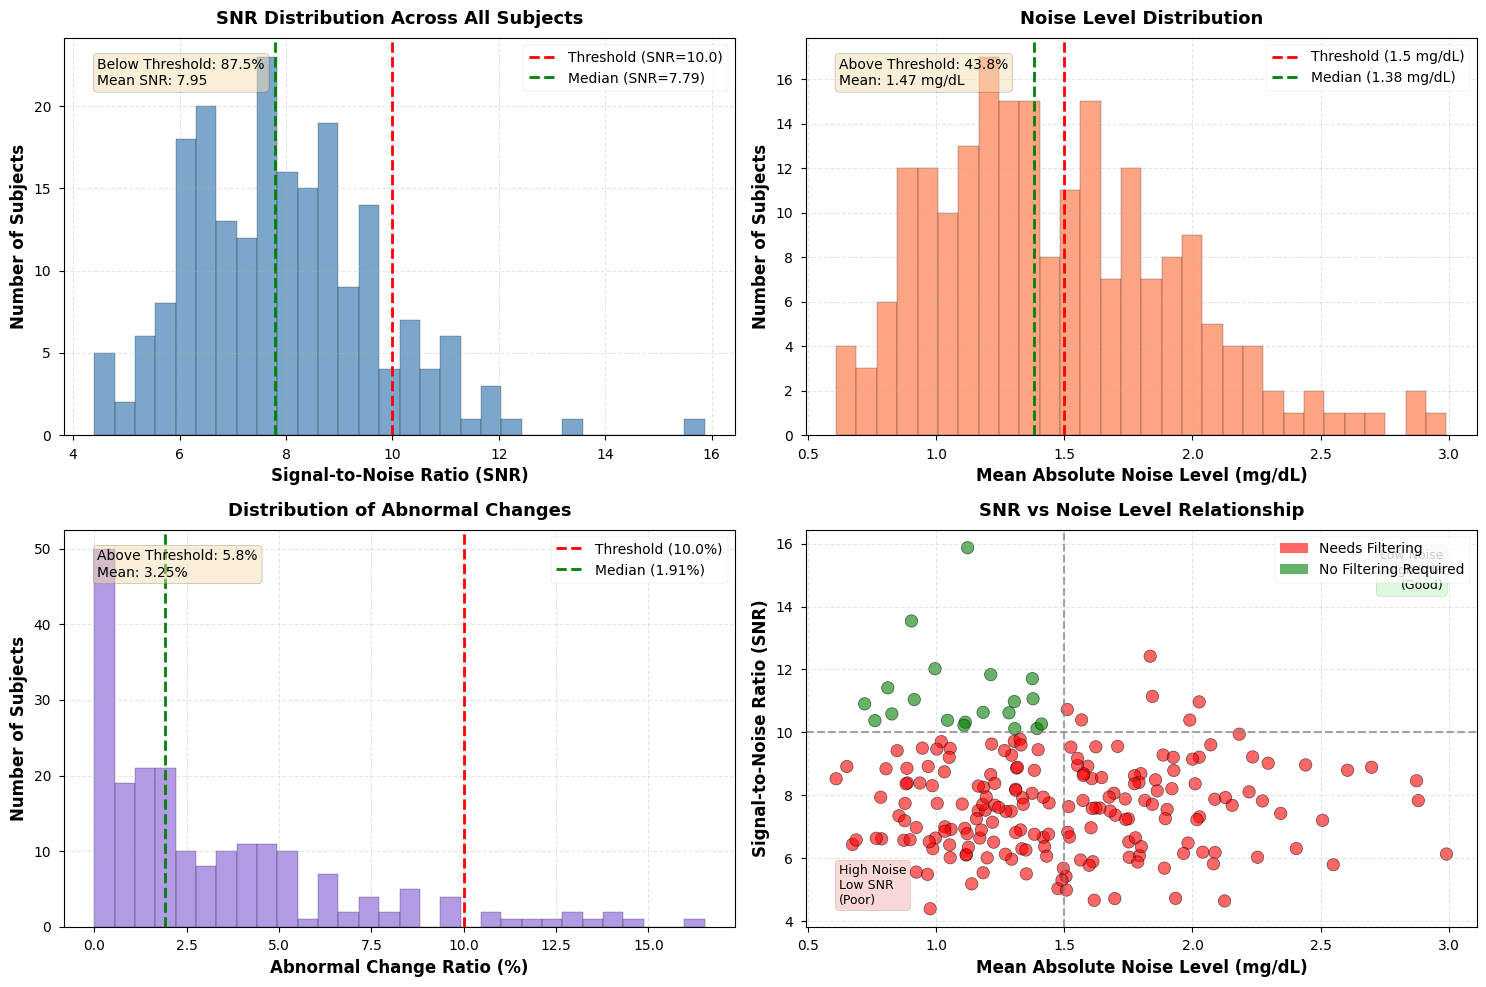


可视化分析总结:
从上述四个子图可以看出：
  1. SNR分布: 87.5% 受试者的SNR低于阈值(10.0)，表明噪声显著
  2. 噪声水平: 43.8% 受试者的噪声水平高于阈值(1.5 mg/dL)
  3. 异常跳变: 5.8% 受试者存在过多异常跳变(>10.0%)
  4. 散点图显示: 红色点(需要滤波)占据主要分布区域

结论: 数据普遍存在噪声问题，滤波处理对提升模型性能至关重要


In [41]:
# 图2: 信噪比(SNR)分布直方图 - 论证滤波必要性
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 子图1: SNR分布直方图
ax1 = axes[0, 0]
ax1.hist(noise_df['snr'], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(SNR_THRESHOLD, color='red', linestyle='--', linewidth=2, 
            label=f'Threshold (SNR={SNR_THRESHOLD})')
ax1.axvline(noise_df['snr'].median(), color='green', linestyle='--', linewidth=2, 
            label=f'Median (SNR={noise_df["snr"].median():.2f})')
ax1.set_xlabel('Signal-to-Noise Ratio (SNR)', fontweight='bold')
ax1.set_ylabel('Number of Subjects', fontweight='bold')
ax1.set_title('SNR Distribution Across All Subjects', fontweight='bold', pad=10)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3, linestyle='--')

# 添加统计文本
low_snr_pct = (noise_df['snr'] < SNR_THRESHOLD).sum() / len(noise_df) * 100
ax1.text(0.05, 0.95, f'Below Threshold: {low_snr_pct:.1f}%\nMean SNR: {noise_df["snr"].mean():.2f}', 
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 子图2: 噪声水平分布
ax2 = axes[0, 1]
ax2.hist(noise_df['noise_mean_abs'], bins=30, color='coral', alpha=0.7, edgecolor='black')
ax2.axvline(NOISE_THRESHOLD, color='red', linestyle='--', linewidth=2, 
            label=f'Threshold ({NOISE_THRESHOLD} mg/dL)')
ax2.axvline(noise_df['noise_mean_abs'].median(), color='green', linestyle='--', linewidth=2, 
            label=f'Median ({noise_df["noise_mean_abs"].median():.2f} mg/dL)')
ax2.set_xlabel('Mean Absolute Noise Level (mg/dL)', fontweight='bold')
ax2.set_ylabel('Number of Subjects', fontweight='bold')
ax2.set_title('Noise Level Distribution', fontweight='bold', pad=10)
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3, linestyle='--')

high_noise_pct = (noise_df['noise_mean_abs'] > NOISE_THRESHOLD).sum() / len(noise_df) * 100
ax2.text(0.05, 0.95, f'Above Threshold: {high_noise_pct:.1f}%\nMean: {noise_df["noise_mean_abs"].mean():.2f} mg/dL', 
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 子图3: 异常跳变比例分布
ax3 = axes[1, 0]
ax3.hist(noise_df['abnormal_ratio'], bins=30, color='mediumpurple', alpha=0.7, edgecolor='black')
ax3.axvline(ABNORMAL_THRESHOLD, color='red', linestyle='--', linewidth=2, 
            label=f'Threshold ({ABNORMAL_THRESHOLD}%)')
ax3.axvline(noise_df['abnormal_ratio'].median(), color='green', linestyle='--', linewidth=2, 
            label=f'Median ({noise_df["abnormal_ratio"].median():.2f}%)')
ax3.set_xlabel('Abnormal Change Ratio (%)', fontweight='bold')
ax3.set_ylabel('Number of Subjects', fontweight='bold')
ax3.set_title('Distribution of Abnormal Changes', fontweight='bold', pad=10)
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3, linestyle='--')

high_abnormal_pct = (noise_df['abnormal_ratio'] > ABNORMAL_THRESHOLD).sum() / len(noise_df) * 100
ax3.text(0.05, 0.95, f'Above Threshold: {high_abnormal_pct:.1f}%\nMean: {noise_df["abnormal_ratio"].mean():.2f}%', 
         transform=ax3.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 子图4: SNR vs 噪声水平散点图
ax4 = axes[1, 1]
colors = ['red' if x else 'green' for x in noise_df['needs_filtering']]
ax4.scatter(noise_df['noise_mean_abs'], noise_df['snr'], 
            c=colors, alpha=0.6, s=80, edgecolor='black', linewidth=0.5)
ax4.axhline(SNR_THRESHOLD, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax4.axvline(NOISE_THRESHOLD, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax4.set_xlabel('Mean Absolute Noise Level (mg/dL)', fontweight='bold')
ax4.set_ylabel('Signal-to-Noise Ratio (SNR)', fontweight='bold')
ax4.set_title('SNR vs Noise Level Relationship', fontweight='bold', pad=10)
ax4.grid(True, alpha=0.3, linestyle='--')

# 添加图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', alpha=0.6, label='Needs Filtering'),
                   Patch(facecolor='green', alpha=0.6, label='No Filtering Required')]
ax4.legend(handles=legend_elements, loc='upper right')

# 添加象限标注
ax4.text(0.95, 0.95, 'Low Noise\nHigh SNR\n(Good)', 
         transform=ax4.transAxes, fontsize=9, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
ax4.text(0.05, 0.05, 'High Noise\nLow SNR\n(Poor)', 
         transform=ax4.transAxes, fontsize=9, ha='left', va='bottom',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("可视化分析总结:")
print("="*70)
print(f"从上述四个子图可以看出：")
print(f"  1. SNR分布: {low_snr_pct:.1f}% 受试者的SNR低于阈值({SNR_THRESHOLD})，表明噪声显著")
print(f"  2. 噪声水平: {high_noise_pct:.1f}% 受试者的噪声水平高于阈值({NOISE_THRESHOLD} mg/dL)")
print(f"  3. 异常跳变: {high_abnormal_pct:.1f}% 受试者存在过多异常跳变(>{ABNORMAL_THRESHOLD}%)")
print(f"  4. 散点图显示: 红色点(需要滤波)占据主要分布区域")
print(f"\n结论: 数据普遍存在噪声问题，滤波处理对提升模型性能至关重要")
print("="*70)

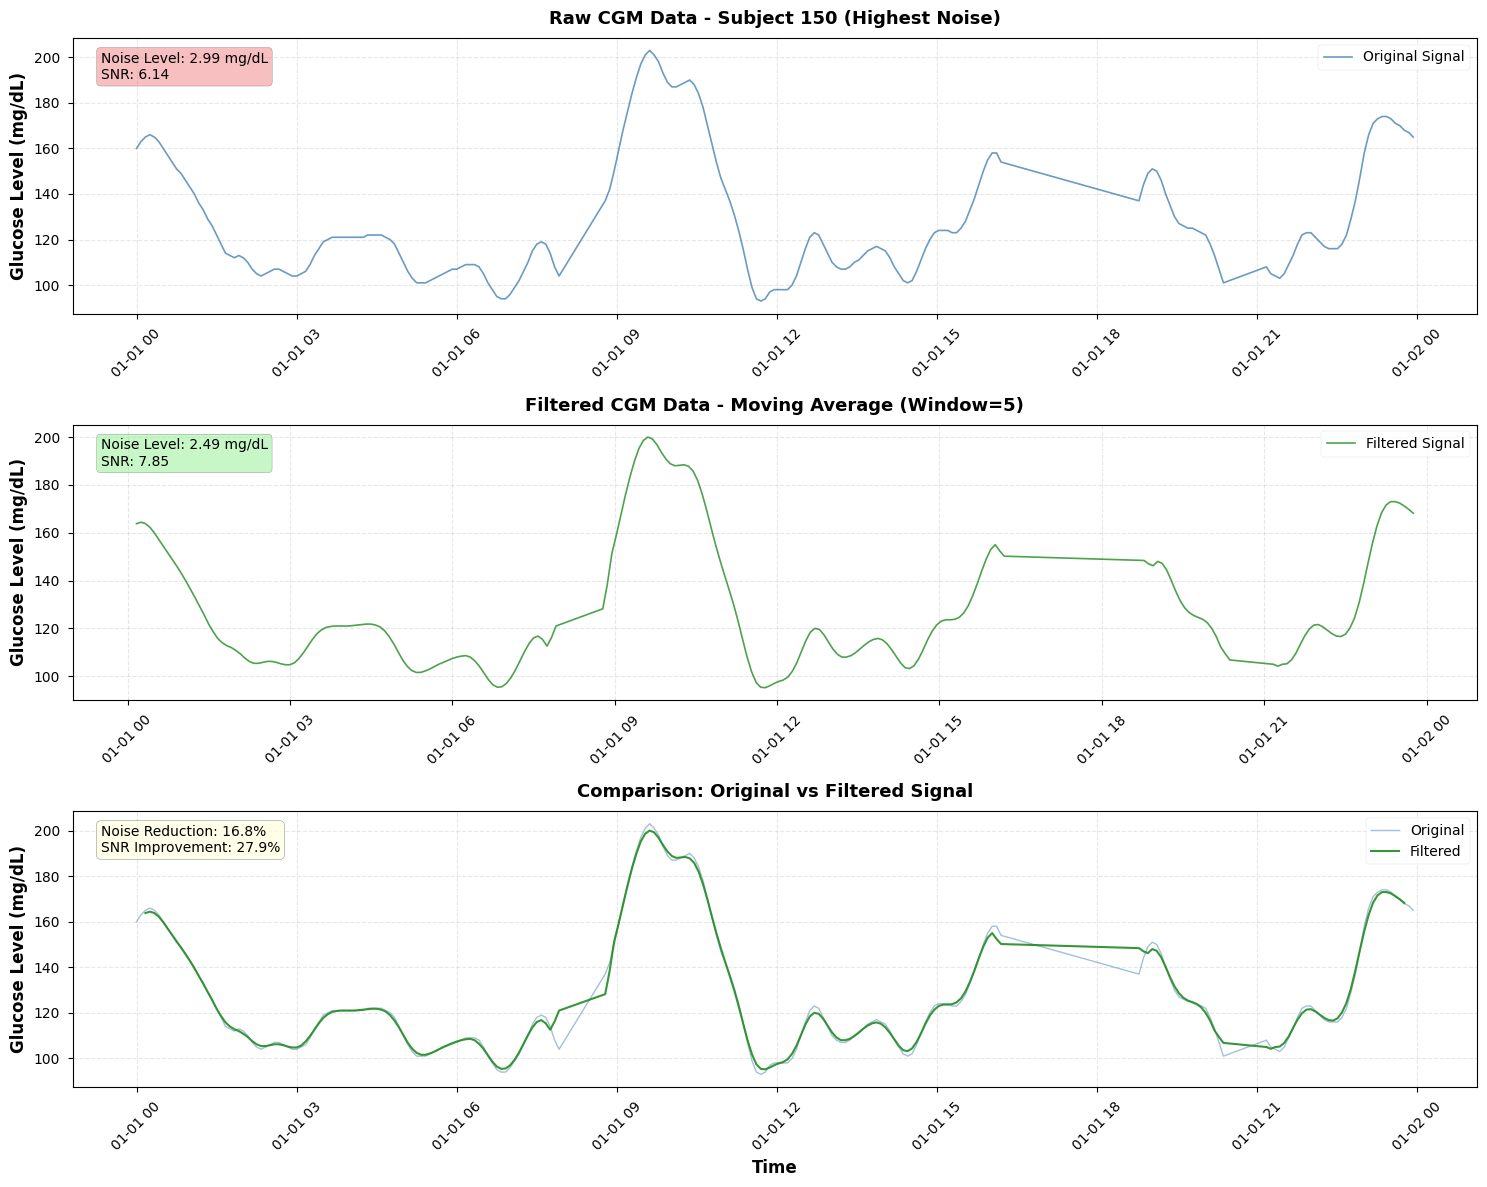


滤波效果评估:
原始数据:
  - 噪声水平: 2.99 mg/dL
  - 信噪比(SNR): 6.14

滤波后数据:
  - 噪声水平: 2.49 mg/dL
  - 信噪比(SNR): 7.85

改善效果:
  - 噪声降低: 16.8%
  - SNR提升: 27.9%

对模型的意义:
  ✓ 减少输入噪声可提高模型预测的稳定性
  ✓ 更高的SNR有助于模型学习真实的生理趋势而非噪声波动
  ✓ 滤波后的平滑数据更适合时序模型(LSTM/Transformer)的训练


In [42]:
# 图3: 滤波前后效果对比示例 - 展示滤波对模型输入质量的改善
# 选择一个高噪声受试者进行演示

# 找出噪声最大的受试者
noisiest_subject = noise_df.loc[noise_df['noise_mean_abs'].idxmax(), 'subject_id']
subject_data = df[df['id'] == noisiest_subject].sort_values('time').reset_index(drop=True)

# 应用简单移动平均滤波作为示例
window_size = 5  # 5点移动平均 (对应25分钟窗口)
subject_data['gl_filtered'] = subject_data['gl'].rolling(window=window_size, center=True).mean()

# 绘制对比图
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# 选择一段数据进行详细对比（例如前500个点）
plot_range = slice(0, 500)
time_subset = subject_data['time'].iloc[plot_range]
gl_original = subject_data['gl'].iloc[plot_range]
gl_filtered = subject_data['gl_filtered'].iloc[plot_range]

# 子图1: 原始数据
axes[0].plot(time_subset, gl_original, linewidth=1.2, alpha=0.8, color='steelblue', label='Original Signal')
axes[0].set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
axes[0].set_title(f'Raw CGM Data - Subject {noisiest_subject} (Highest Noise)', fontweight='bold', pad=10)
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].tick_params(axis='x', rotation=45)

# 添加噪声指标
raw_noise = noise_df[noise_df['subject_id'] == noisiest_subject].iloc[0]
axes[0].text(0.02, 0.95, f'Noise Level: {raw_noise["noise_mean_abs"]:.2f} mg/dL\nSNR: {raw_noise["snr"]:.2f}', 
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

# 子图2: 滤波后数据
axes[1].plot(time_subset, gl_filtered, linewidth=1.2, alpha=0.8, color='forestgreen', label='Filtered Signal')
axes[1].set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
axes[1].set_title(f'Filtered CGM Data - Moving Average (Window={window_size})', fontweight='bold', pad=10)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].tick_params(axis='x', rotation=45)

# 计算滤波后的噪声指标
filtered_diff = gl_filtered.diff().dropna()
filtered_noise = filtered_diff.abs().mean()
filtered_signal_std = gl_filtered.std()
filtered_snr = filtered_signal_std / filtered_diff.std() if filtered_diff.std() > 0 else 0

axes[1].text(0.02, 0.95, f'Noise Level: {filtered_noise:.2f} mg/dL\nSNR: {filtered_snr:.2f}', 
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# 子图3: 叠加对比
axes[2].plot(time_subset, gl_original, linewidth=1.0, alpha=0.5, color='steelblue', label='Original')
axes[2].plot(time_subset, gl_filtered, linewidth=1.5, alpha=0.9, color='forestgreen', label='Filtered')
axes[2].set_xlabel('Time', fontweight='bold')
axes[2].set_ylabel('Glucose Level (mg/dL)', fontweight='bold')
axes[2].set_title('Comparison: Original vs Filtered Signal', fontweight='bold', pad=10)
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3, linestyle='--')
axes[2].tick_params(axis='x', rotation=45)

# 计算改善百分比
noise_reduction = (raw_noise['noise_mean_abs'] - filtered_noise) / raw_noise['noise_mean_abs'] * 100
snr_improvement = (filtered_snr - raw_noise['snr']) / raw_noise['snr'] * 100

axes[2].text(0.02, 0.95, 
             f'Noise Reduction: {noise_reduction:.1f}%\nSNR Improvement: {snr_improvement:.1f}%', 
             transform=axes[2].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("滤波效果评估:")
print("="*70)
print(f"原始数据:")
print(f"  - 噪声水平: {raw_noise['noise_mean_abs']:.2f} mg/dL")
print(f"  - 信噪比(SNR): {raw_noise['snr']:.2f}")
print(f"\n滤波后数据:")
print(f"  - 噪声水平: {filtered_noise:.2f} mg/dL")
print(f"  - 信噪比(SNR): {filtered_snr:.2f}")
print(f"\n改善效果:")
print(f"  - 噪声降低: {noise_reduction:.1f}%")
print(f"  - SNR提升: {snr_improvement:.1f}%")
print(f"\n对模型的意义:")
print(f"  ✓ 减少输入噪声可提高模型预测的稳定性")
print(f"  ✓ 更高的SNR有助于模型学习真实的生理趋势而非噪声波动")
print(f"  ✓ 滤波后的平滑数据更适合时序模型(LSTM/Transformer)的训练")
print("="*70)